In [1]:
#%load_ext autoreload
#%autoreload 2

In [2]:
import torch
import os
import sys
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT


# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score

def seed_torch(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    #add to warn
    #torch.use_deterministic_algorithms(True, warn_only=True) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(seed=42)


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [4]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

# Setup

In [5]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
dataset = GAResearchDataset(root ='tmp/roman-fasttext-custom', name='roman-fasttext')

In [6]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 300
Number of num_classes : 18
Number of num_nodes : 22600
Number of num_edges : 65368


In [7]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([22600, 10])
torch.Size([22600, 10])
torch.Size([22600, 10])


In [8]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([ True, False,  True,  ...,  True, False,  True])
torch.Size([22600])


In [9]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1).cpu().numpy()
        y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    #f1 = f1_score(y, pred, average='micro', zero_division=0)
    acc = accuracy_score(y, pred)

    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [11]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(18), yticklabels=range(18))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    return model, train_losses, val_f1s, test_f1s, training_time

In [12]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [13]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [14]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


# GCN

Training GCN
Epoch: 010, Loss: 1.9279, Val F1: 0.0748,Val Acc: 0.2208, Time: 0.01s
Epoch: 020, Loss: 1.7341, Val F1: 0.0680,Val Acc: 0.2013, Time: 0.01s
Epoch: 030, Loss: 1.6161, Val F1: 0.1300,Val Acc: 0.2555, Time: 0.01s
Epoch: 040, Loss: 1.5110, Val F1: 0.2022,Val Acc: 0.2929, Time: 0.01s
Epoch: 050, Loss: 1.4065, Val F1: 0.2691,Val Acc: 0.3153, Time: 0.01s
Epoch: 060, Loss: 1.3000, Val F1: 0.2762,Val Acc: 0.3088, Time: 0.01s
Epoch: 070, Loss: 1.2059, Val F1: 0.2756,Val Acc: 0.2967, Time: 0.01s
Epoch: 080, Loss: 1.1180, Val F1: 0.2501,Val Acc: 0.2850, Time: 0.01s
Epoch: 090, Loss: 1.0334, Val F1: 0.2397,Val Acc: 0.2852, Time: 0.01s
Epoch: 100, Loss: 0.9612, Val F1: 0.2351,Val Acc: 0.2748, Time: 0.01s
Test F1: 0.2632
Test Accuracy: 0.3080


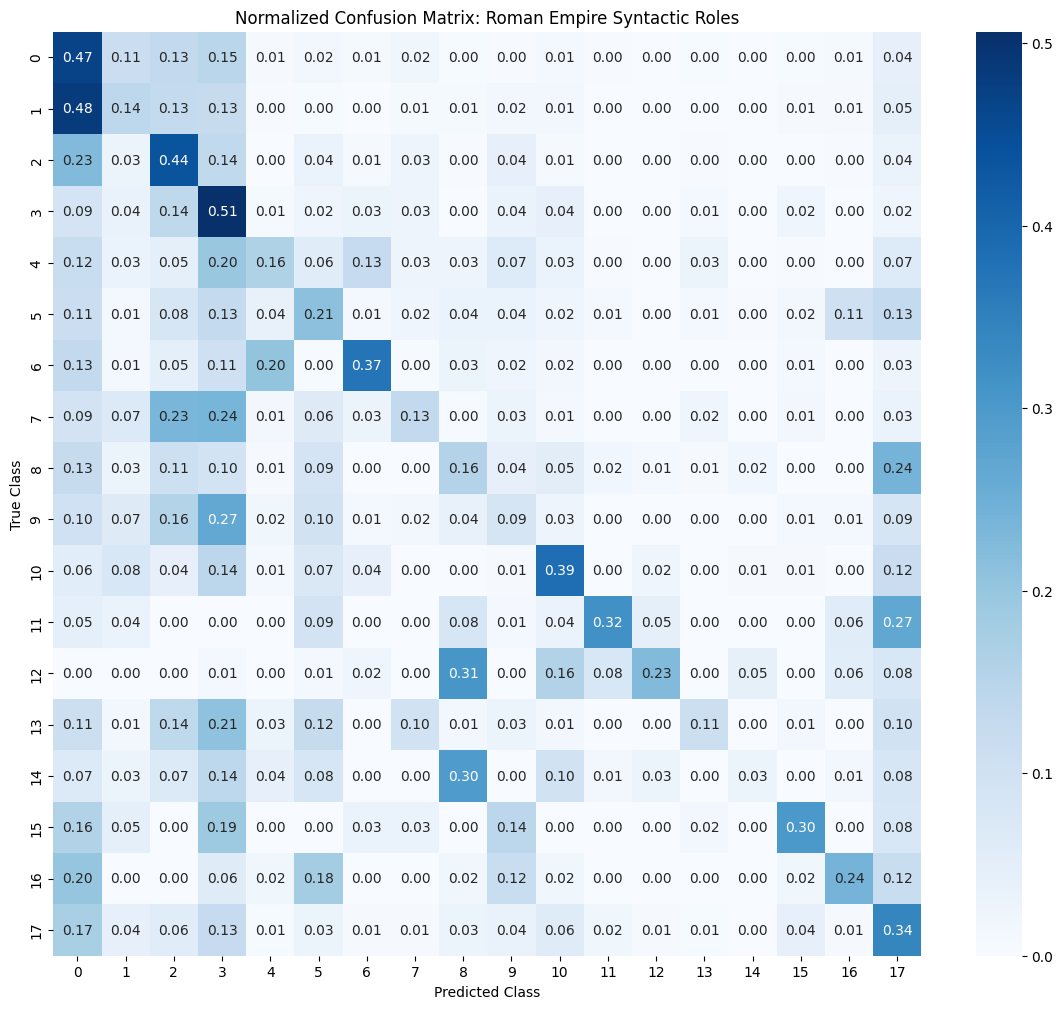

Training Time 9.329436540603638


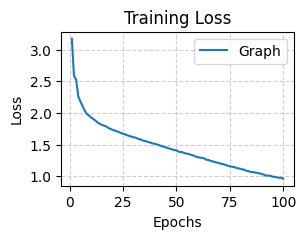

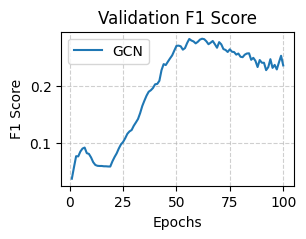

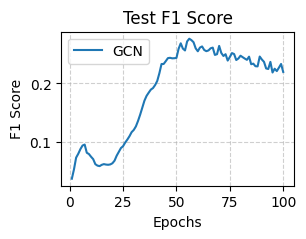

In [15]:
gcn_run()

In [16]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 1.1246, Val F1: 0.4848,Val Acc: 0.6445, Time: 0.01s
Epoch: 020, Loss: 0.7808, Val F1: 0.6305,Val Acc: 0.7219, Time: 0.01s
Epoch: 030, Loss: 0.5931, Val F1: 0.6925,Val Acc: 0.7653, Time: 0.01s
Epoch: 040, Loss: 0.4610, Val F1: 0.7375,Val Acc: 0.7945, Time: 0.01s
Epoch: 050, Loss: 0.3428, Val F1: 0.7412,Val Acc: 0.7969, Time: 0.01s
Epoch: 060, Loss: 0.2586, Val F1: 0.7652,Val Acc: 0.8073, Time: 0.01s
Epoch: 070, Loss: 0.1860, Val F1: 0.7652,Val Acc: 0.8084, Time: 0.01s
Epoch: 080, Loss: 0.1303, Val F1: 0.7720,Val Acc: 0.8157, Time: 0.01s
Epoch: 090, Loss: 0.0918, Val F1: 0.7760,Val Acc: 0.8184, Time: 0.01s
Epoch: 100, Loss: 0.0696, Val F1: 0.7800,Val Acc: 0.8186, Time: 0.01s
Test F1: 0.7750
Test Accuracy: 0.8166


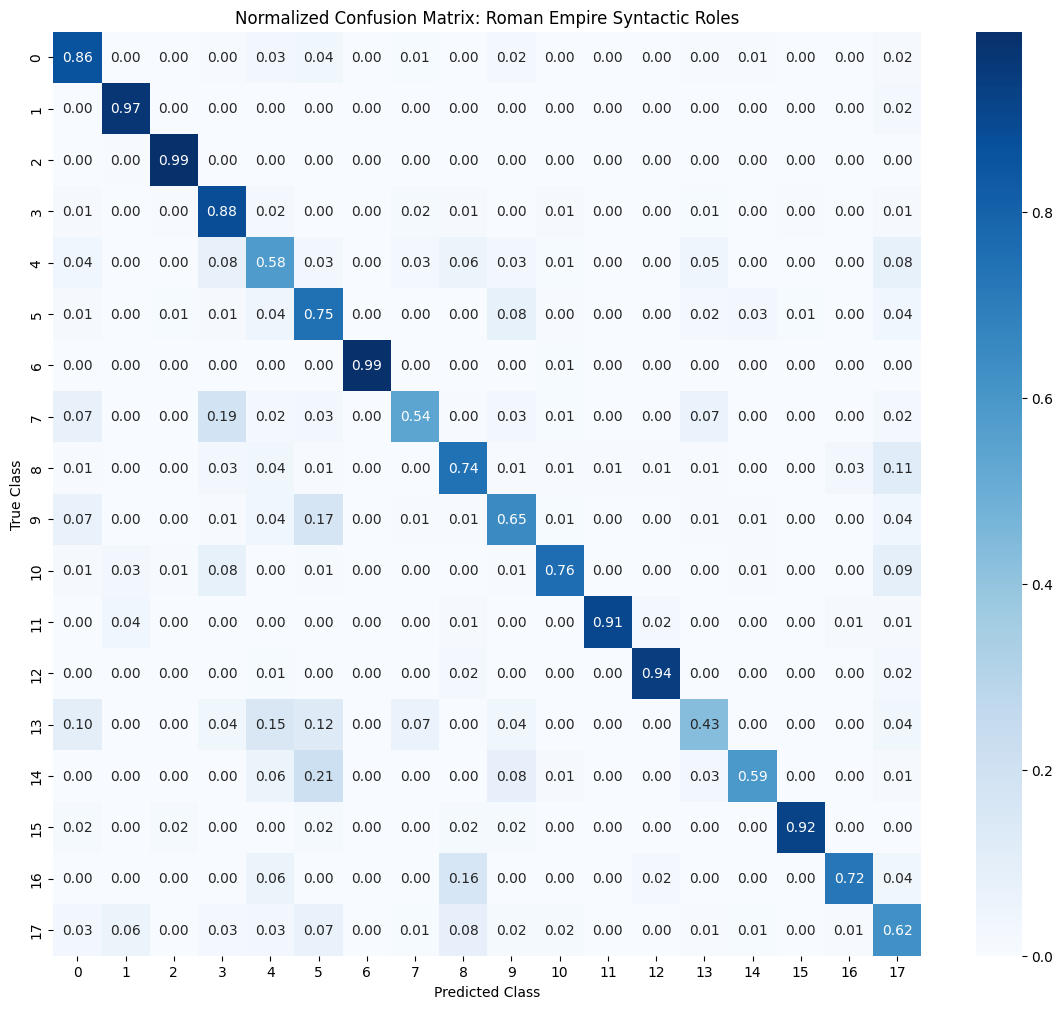

Training Time 1.1734802722930908


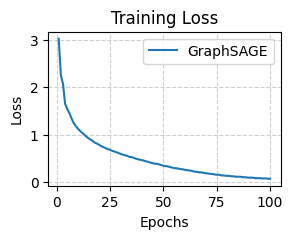

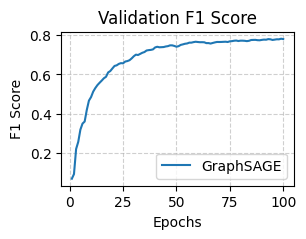

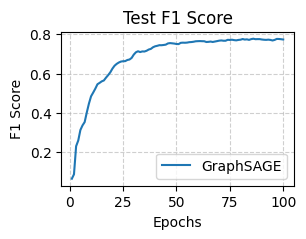

In [17]:
graphSage_run()

In [18]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 2.3921, Val F1: 0.0483,Val Acc: 0.1555, Time: 0.02s
Epoch: 020, Loss: 2.1774, Val F1: 0.1239,Val Acc: 0.2646, Time: 0.02s
Epoch: 030, Loss: 2.0507, Val F1: 0.1778,Val Acc: 0.2918, Time: 0.02s
Epoch: 040, Loss: 1.9664, Val F1: 0.2505,Val Acc: 0.3179, Time: 0.02s
Epoch: 050, Loss: 1.8998, Val F1: 0.2891,Val Acc: 0.3219, Time: 0.02s
Epoch: 060, Loss: 1.8449, Val F1: 0.2714,Val Acc: 0.2993, Time: 0.02s
Epoch: 070, Loss: 1.7920, Val F1: 0.2771,Val Acc: 0.3020, Time: 0.02s
Epoch: 080, Loss: 1.7308, Val F1: 0.2778,Val Acc: 0.2954, Time: 0.02s
Epoch: 090, Loss: 1.6829, Val F1: 0.2747,Val Acc: 0.2993, Time: 0.02s
Epoch: 100, Loss: 1.6243, Val F1: 0.2391,Val Acc: 0.2608, Time: 0.02s
Test F1: 0.2818
Test Accuracy: 0.3159


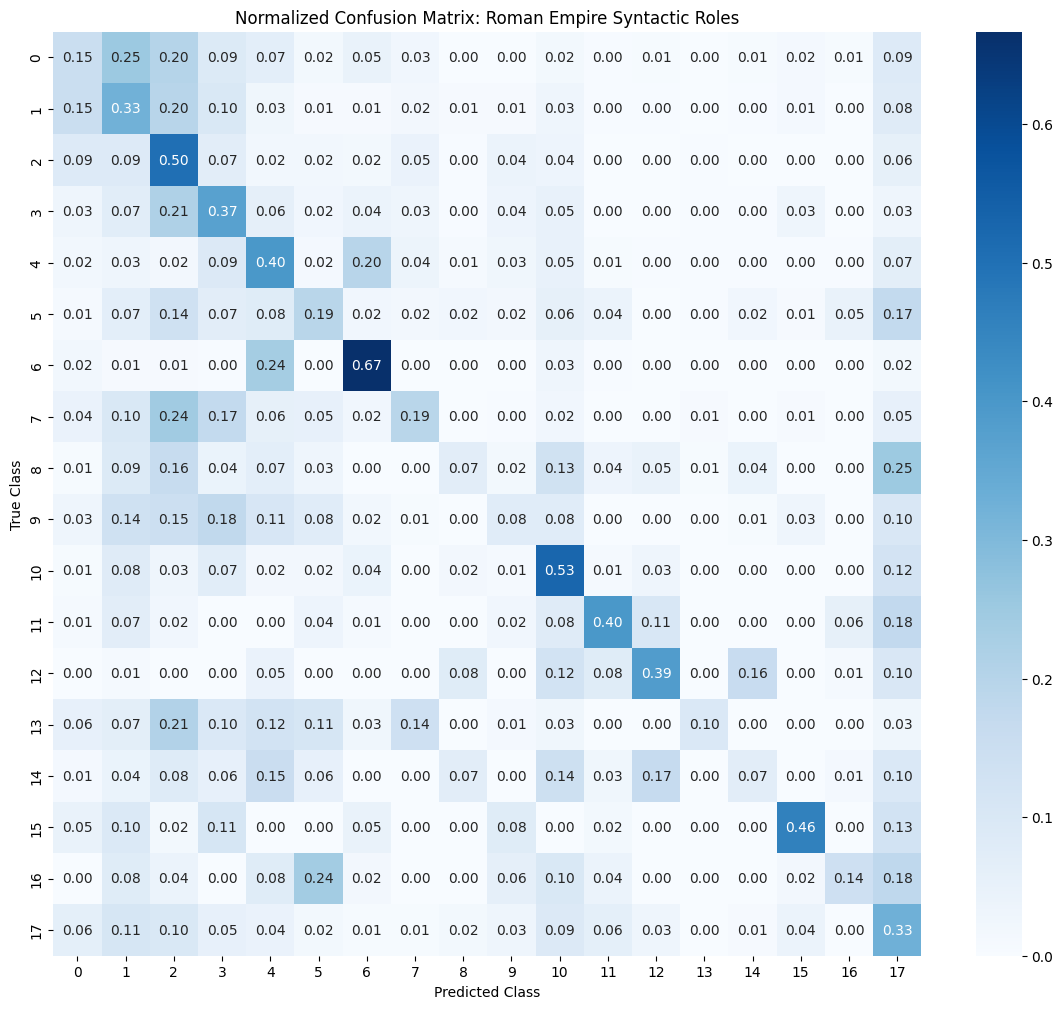

Training Time 3.096616744995117


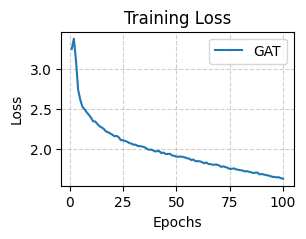

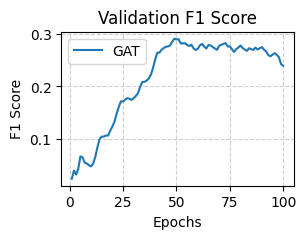

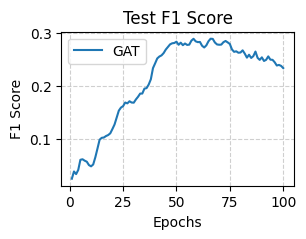

In [19]:
gat_run()

# GCN2Conv

In [23]:
from GCN2 import GCN2

In [ ]:
args = {
      'device': device,
      'num_layers': 30,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [25]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 2.6675, Val F1: 0.0147,Val Acc: 0.1529, Time: 0.12s
Epoch: 020, Loss: 2.5430, Val F1: 0.0310,Val Acc: 0.1670, Time: 0.12s
Epoch: 030, Loss: 2.4258, Val F1: 0.0433,Val Acc: 0.2029, Time: 0.12s
Epoch: 040, Loss: 2.2824, Val F1: 0.0778,Val Acc: 0.2542, Time: 0.13s
Epoch: 050, Loss: 2.0615, Val F1: 0.1338,Val Acc: 0.3347, Time: 0.12s
Epoch: 060, Loss: 1.7403, Val F1: 0.1496,Val Acc: 0.3825, Time: 0.12s
Epoch: 070, Loss: 1.3760, Val F1: 0.1467,Val Acc: 0.4055, Time: 0.12s
Epoch: 080, Loss: 1.0893, Val F1: 0.2405,Val Acc: 0.4940, Time: 0.12s
Epoch: 090, Loss: 0.8728, Val F1: 0.3670,Val Acc: 0.5697, Time: 0.13s
Epoch: 100, Loss: 0.7231, Val F1: 0.4319,Val Acc: 0.5679, Time: 0.12s
Epoch: 110, Loss: 0.6014, Val F1: 0.4648,Val Acc: 0.5803, Time: 0.12s
Epoch: 120, Loss: 0.4959, Val F1: 0.4593,Val Acc: 0.5558, Time: 0.12s
Epoch: 130, Loss: 0.4109, Val F1: 0.4198,Val Acc: 0.5228, Time: 0.12s
Epoch: 140, Loss: 0.3349, Val F1: 0.4131,Val Acc: 0.5091, Time: 0.12s
Epoch: 

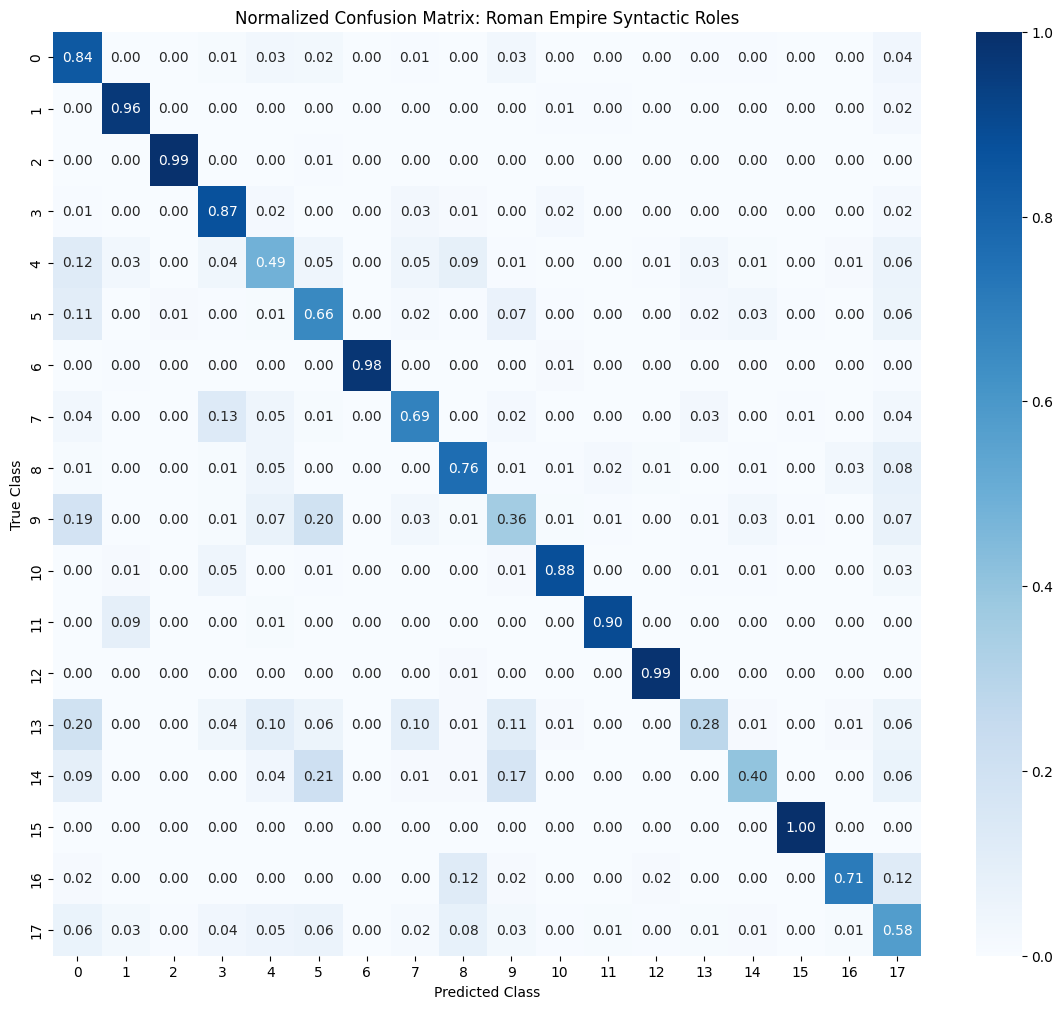

Training Time 50.12103271484375


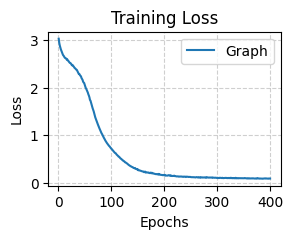

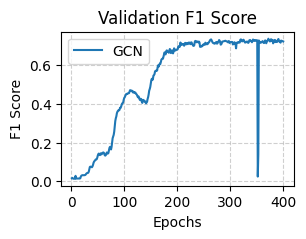

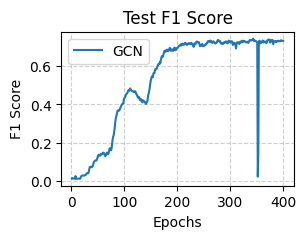

In [26]:
gcn2_run()

# H2GCN

In [27]:
from H2GCN import H2GCN

In [ ]:
args = {
      'device': device,
      'num_layers': 30, #Not applicable to H2GCN
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [29]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 1.4273, Val F1: 0.2591,Val Acc: 0.4319, Time: 0.01s
Epoch: 020, Loss: 1.0460, Val F1: 0.2148,Val Acc: 0.3569, Time: 0.01s
Epoch: 030, Loss: 0.8486, Val F1: 0.2832,Val Acc: 0.3945, Time: 0.01s
Epoch: 040, Loss: 0.7086, Val F1: 0.3253,Val Acc: 0.4350, Time: 0.01s
Epoch: 050, Loss: 0.6048, Val F1: 0.3556,Val Acc: 0.4646, Time: 0.01s
Epoch: 060, Loss: 0.5354, Val F1: 0.3943,Val Acc: 0.4978, Time: 0.01s
Epoch: 070, Loss: 0.4868, Val F1: 0.4986,Val Acc: 0.6144, Time: 0.01s
Epoch: 080, Loss: 0.4377, Val F1: 0.6071,Val Acc: 0.7031, Time: 0.01s
Epoch: 090, Loss: 0.4096, Val F1: 0.6613,Val Acc: 0.7308, Time: 0.01s
Epoch: 100, Loss: 0.3899, Val F1: 0.6577,Val Acc: 0.7254, Time: 0.01s
Epoch: 110, Loss: 0.3578, Val F1: 0.6667,Val Acc: 0.7398, Time: 0.01s
Epoch: 120, Loss: 0.3418, Val F1: 0.6577,Val Acc: 0.7338, Time: 0.01s
Epoch: 130, Loss: 0.3265, Val F1: 0.6670,Val Acc: 0.7394, Time: 0.01s
Epoch: 140, Loss: 0.3143, Val F1: 0.6599,Val Acc: 0.7310, Time: 0.01s
Epoch

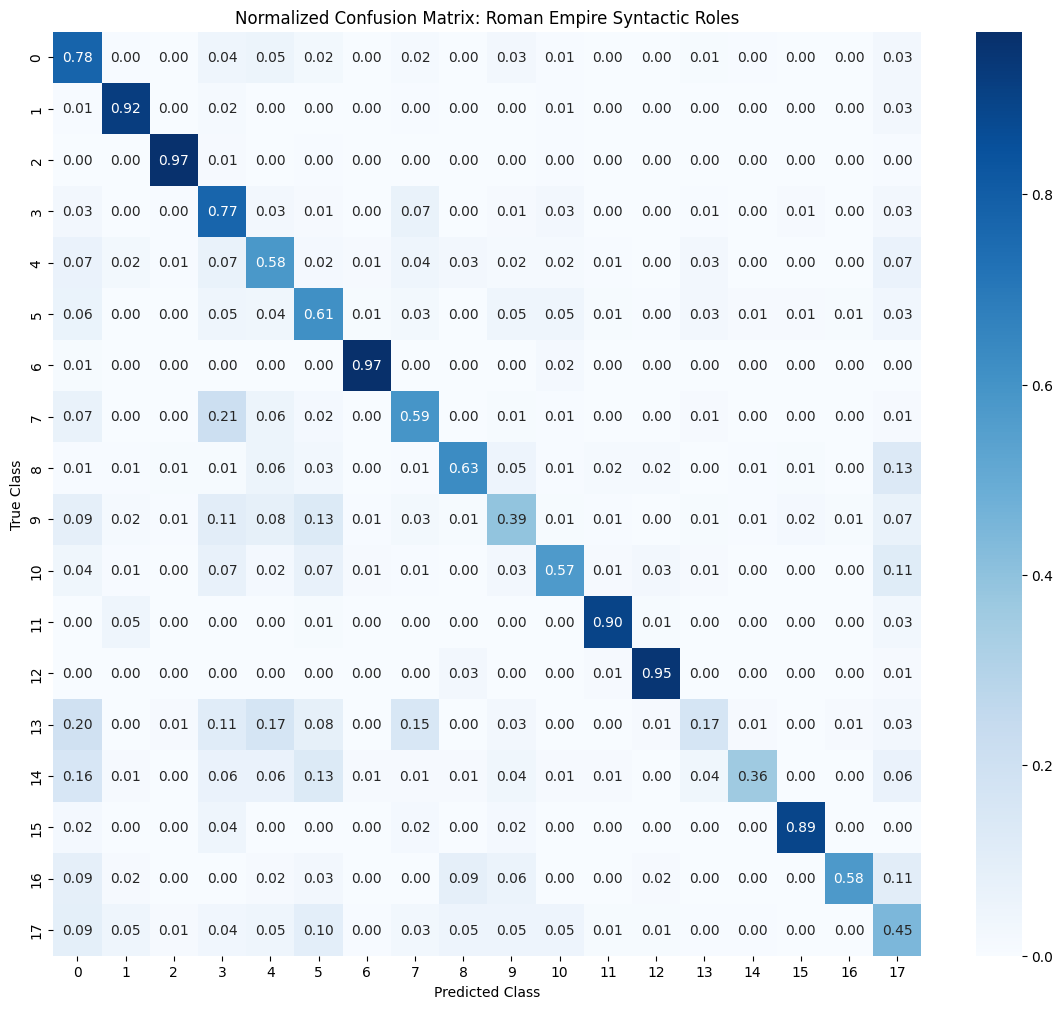

Training Time 3.5391032695770264


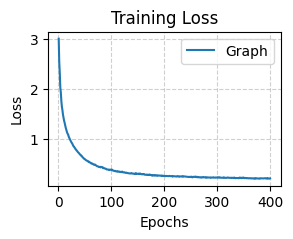

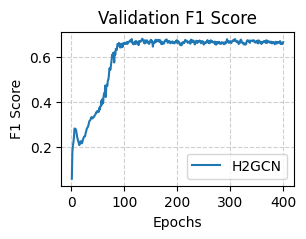

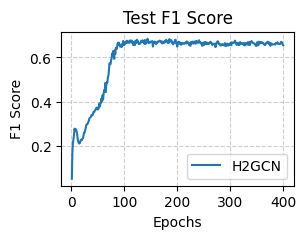

In [30]:
h2GCN_run()